## Tarea 2 Unidad 1 - Introducción a la IA: Machine Learning Procesamiento de datos
### 2. SVM
Alan Josue Solano Perez

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score
from sklearn.decomposition import PCA

## 1. Cargar los Datos y Preprocesamiento
Seleccionaremos las variables relacionadas con muertes de torres, inhibidores, barones, dragones, y el tiempo de juego para predecir al ganador (`winner`).
Dado que SVM puede ser muy demandante computacionalmente con grandes volúmenes de datos, tomaremos una muestra de 2000 partidas para acelerar el entrenamiento.

In [3]:
# Cargamos la data
df = pd.read_csv('../data/LOL/games.csv')

df.head()

,gameId,creationTime,gameDuration,seasonId,winner,firstBlood,firstTower,firstInhibitor,firstBaron,firstDragon,...,t2_towerKills,t2_inhibitorKills,t2_baronKills,t2_dragonKills,t2_riftHeraldKills,t2_ban1,t2_ban2,t2_ban3,t2_ban4,t2_ban5
0,3326086514,1504279457970,1949,9,1,2,1,1,1,1,...,5,0,0,1,1,114,67,43,16,51
1,3229566029,1497848803862,1851,9,1,1,1,1,0,1,...,2,0,0,0,0,11,67,238,51,420
2,3327363504,1504360103310,1493,9,1,2,1,1,1,2,...,2,0,0,1,0,157,238,121,57,28
3,3326856598,1504348503996,1758,9,1,1,1,1,1,1,...,0,0,0,0,0,164,18,141,40,51
4,3330080762,1504554410899,2094,9,1,2,1,1,1,1,...,3,0,0,1,0,86,11,201,122,18


In [4]:
# Seleccionar columnas relevantes para features y el target 'winner' (1 o 2)
features = [
    'gameDuration', 'firstBlood', 'firstTower', 'firstInhibitor', 
    'firstBaron', 'firstDragon', 't1_towerKills', 't1_inhibitorKills', 
    't1_baronKills', 't1_dragonKills', 't2_towerKills', 't2_inhibitorKills', 
    't2_baronKills', 't2_dragonKills'
]

# Tomar una muestra representativa para entrenar más rápido
df_sample = df.sample(n=2000, random_state=42)

X = df_sample[features]
y = df_sample['winner']

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Estandarización de características (Crucial para algoritmos SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 2. SVM Lineal en 2D
Aplicaremos PCA para reducir las dimensiones de nuestros datos a solo 2 componentes principales y así poder graficar la frontera de decisión y los márgenes.

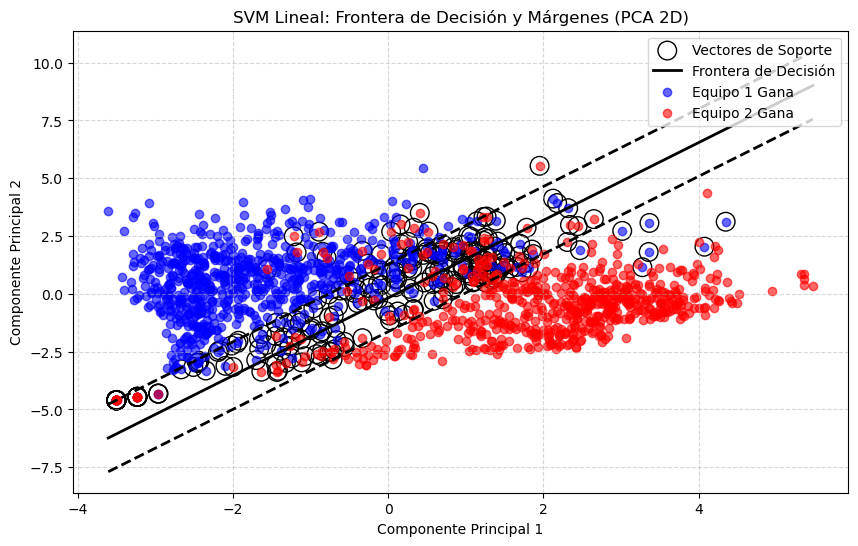

In [5]:
# Reducir los datos a 2 dimensiones con PCA
pca_2d = PCA(n_components=2)
X_train_pca2 = pca_2d.fit_transform(X_train_scaled)

# Entrenar SVM con kernel Lineal
svm_linear = SVC(kernel='linear', C=1.0)
svm_linear.fit(X_train_pca2, y_train)

# Función para graficar la frontera de decisión
def plot_svc_decision_boundary(svm_clf, xmin, xmax):
    w = svm_clf.coef_[0]
    b = svm_clf.intercept_[0]
    
    x0 = np.linspace(xmin, xmax, 200)
    decision_boundary = -w[0]/w[1] * x0 - b/w[1]
    
    margin = 1/w[1]
    gutter_up = decision_boundary + margin
    gutter_down = decision_boundary - margin
    
    svs = svm_clf.support_vectors_
    plt.scatter(svs[:, 0], svs[:, 1], s=180, facecolors='none', edgecolors='k', label='Vectores de Soporte')
    plt.plot(x0, decision_boundary, "k-", linewidth=2, label='Frontera de Decisión')
    plt.plot(x0, gutter_up, "k--", linewidth=2)
    plt.plot(x0, gutter_down, "k--", linewidth=2)

# Configurar el gráfico
plt.figure(figsize=(10, 6))
plot_svc_decision_boundary(svm_linear, xmin=X_train_pca2[:, 0].min(), xmax=X_train_pca2[:, 0].max())

# Graficar los puntos de las partidas
plt.scatter(X_train_pca2[y_train==1, 0], X_train_pca2[y_train==1, 1], color='blue', label='Equipo 1 Gana', alpha=0.6)
plt.scatter(X_train_pca2[y_train==2, 0], X_train_pca2[y_train==2, 1], color='red', label='Equipo 2 Gana', alpha=0.6)

plt.title('SVM Lineal: Frontera de Decisión y Márgenes (PCA 2D)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## 3. SVM con Kernel RBF en 3D
Para el enfoque no lineal, reduciremos a 3 componentes y usaremos el kernel Radial (RBF). Visualizaremos el espacio tridimensional resaltando los vectores de soporte.

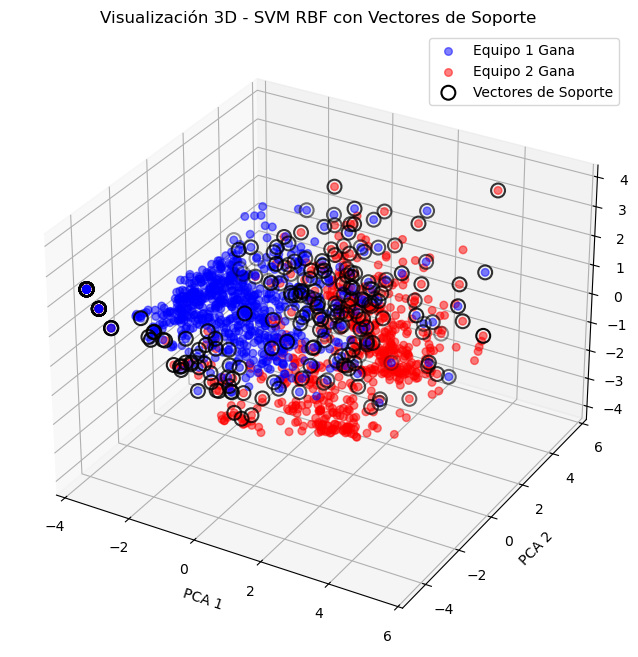

In [6]:
# Reducir los datos a 3 dimensiones con PCA
pca_3d = PCA(n_components=3)
X_train_pca3 = pca_3d.fit_transform(X_train_scaled)

# Entrenar SVM con RBF
svm_rbf = SVC(kernel='rbf', C=1.0, gamma='scale')
svm_rbf.fit(X_train_pca3, y_train)

# Configuración del gráfico 3D
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Graficar Clase 1 (Equipo 1 Gana)
ax.scatter(X_train_pca3[y_train == 1, 0], X_train_pca3[y_train == 1, 1], X_train_pca3[y_train == 1, 2], 
           color='blue', label='Equipo 1 Gana', alpha=0.5, s=30)

# Graficar Clase 2 (Equipo 2 Gana)
ax.scatter(X_train_pca3[y_train == 2, 0], X_train_pca3[y_train == 2, 1], X_train_pca3[y_train == 2, 2], 
           color='red', label='Equipo 2 Gana', alpha=0.5, s=30)

# Resaltar Vectores de Soporte
sv = svm_rbf.support_vectors_
ax.scatter(sv[:, 0], sv[:, 1], sv[:, 2], s=100, facecolors='none', edgecolors='black', linewidths=1.5, label='Vectores de Soporte')

ax.set_xlabel('PCA 1')
ax.set_ylabel('PCA 2')
ax.set_zlabel('PCA 3')
ax.set_title('Visualización 3D - SVM RBF con Vectores de Soporte')
ax.legend()
plt.show()

## 4. Entrenamiento y Evaluación sobre las Características Originales
Las visualizaciones previas dependen de PCA para la reducción de dimensiones. A continuación, entrenaremos el modelo utilizando todas las variables originales estandarizadas para conocer su precisión real.

In [7]:
# Entrenar el modelo final usando el conjunto de entrenamiento escalado completo
svm_final = SVC(kernel='rbf', C=1.0)
svm_final.fit(X_train_scaled, y_train)

# Predicciones
y_pred = svm_final.predict(X_test_scaled)

# Resultados
print(f"Precisión General (Accuracy): {accuracy_score(y_test, y_pred)*100:.2f}%\n")
print("Reporte de Clasificación:")
print(classification_report(y_test, y_pred, target_names=['Gana Equipo 1', 'Gana Equipo 2']))

Precisión General (Accuracy): 95.17%

Reporte de Clasificación:
               precision    recall  f1-score   support

Gana Equipo 1       0.95      0.97      0.96       325
Gana Equipo 2       0.96      0.93      0.95       275

     accuracy                           0.95       600
    macro avg       0.95      0.95      0.95       600
 weighted avg       0.95      0.95      0.95       600

